## Import & Setup

In [1]:
import cv2
import os
import time
import pandas as pd
import numpy as np
from pyzbar import pyzbar

## 1. Threshold setting


In [2]:
# =========================
# THRESHOLD SETTINGS
# =========================
BLUR_THRESHOLD = 100.0
CONTRAST_THRESHOLD = 50.0
BRIGHTNESS_THRESHOLD = 80.0
MANUAL_THRESHOLD = 127
ANGLE_PASS_MAX = 15
ANGLE_REJECT_MAX = 30


## 2. Read image


In [3]:
def load_image(path, size=(640, 480)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    return img

## 3. Preprocessing

In [4]:
# def preprocess_image(img):
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     brightness = float(np.mean(gray))

#     # manual threshold only (Retinex removed)
#     _, enhanced = cv2.threshold(gray, MANUAL_THRESHOLD, 255, cv2.THRESH_BINARY)
#     method = "MANUAL_THRESHOLD"

#     _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     adaptive = cv2.adaptiveThreshold(
#         gray,
#         255,
#         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#         cv2.THRESH_BINARY,
#         11,
#         2
#     )

#     return {
#         "gray": gray,
#         "enhanced": enhanced,
#         "otsu": otsu,
#         "adaptive": adaptive,
#         "brightness": brightness,
#         "method": method
#     }


In [5]:
def preprocess_image(img, manual_threshold=140):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))

    _, enhanced = cv2.threshold(gray, manual_threshold, 255, cv2.THRESH_BINARY)
    method = f"MANUAL_THRESHOLD_{manual_threshold}"

    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    adaptive = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return {
        "gray": gray,
        "enhanced": enhanced,
        "otsu": otsu,
        "adaptive": adaptive,
        "brightness": brightness,
        "method": method
    }

## 4. Quality Inspection

In [6]:
def quality_inspection(preprocessed):
    enhanced = preprocessed["enhanced"]

    # blur
    blur = cv2.Laplacian(enhanced, cv2.CV_64F).var()

    # contrast / dynamic range
    contrast = float(enhanced.max() - enhanced.min())

    return {
        "blur": float(blur),
        "contrast": contrast
    }

## 5. Decision Logic 1

In [7]:
def decision_logic_1(quality_metrics):
    blur = quality_metrics["blur"]
    contrast = quality_metrics["contrast"]

    if blur < BLUR_THRESHOLD:
        return "REJECT", "BLUR"

    if contrast < CONTRAST_THRESHOLD:
        return "REJECT", "LOW_CONTRAST"

    return "PASS", "QUALITY_OK"

## 6. Qr detection & decode

In [8]:
def estimate_qr_angle(decoded_obj):
    pts = decoded_obj.polygon

    if pts is None or len(pts) < 2:
        return None

    p1 = pts[0]
    p2 = pts[1]

    angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))

    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    return float(angle)

# def qr_detection(preprocessed):
#     enhanced = preprocessed["enhanced"]

#     decoded = pyzbar.decode(enhanced)

#     if decoded:
#         qr_data = decoded[0].data.decode("utf-8", errors="ignore")
#         angle = estimate_qr_angle(decoded[0])
#         return {
#             "qr_found": True,
#             "qr_data": qr_data,
#             "angle": angle,
#             "decode_method": "PYZBAR"
#         }

#     # fallback using OpenCV QRCodeDetector
#     detector = cv2.QRCodeDetector()

#     try:
#         text, points, _ = detector.detectAndDecode(enhanced)
#     except cv2.error:
#         return {
#             "qr_found": False,
#             "qr_data": "",
#             "angle": None,
#             "decode_method": "ERROR"
#         }

#     if points is not None and len(points) > 0:
#         if text:
#             return {
#                 "qr_found": True,
#                 "qr_data": text,
#                 "angle": None,
#                 "decode_method": "OPENCV_QR"
#             }
#         else:
#             return {
#                 "qr_found": False,
#                 "qr_data": "",
#                 "angle": None,
#                 "decode_method": "QR_SHAPE_ONLY"
#             }

#     return {
#         "qr_found": False,
#         "qr_data": "",
#         "angle": None,
#         "decode_method": "NO_QR"
#     }

def qr_detection(preprocessed):
    enhanced = preprocessed["enhanced"]

    decoded = pyzbar.decode(enhanced)

    # =========================
    # ANGLE CONFIG (ADD HERE)
    # =========================
    ANGLE_PASS_MAX = 15
    ANGLE_REJECT_MAX = 30

    if decoded:
        qr_data = decoded[0].data.decode("utf-8", errors="ignore")
        angle = estimate_qr_angle(decoded[0])

        # =========================
        # ANGLE DECISION (ADD HERE)
        # =========================
        if angle is not None:
            a = abs(angle)

            if a <= ANGLE_PASS_MAX:
                verdict = "PASS"
            elif a >= ANGLE_REJECT_MAX:
                verdict = "REJECT"
                reason = "rotation"
            else:
                verdict = "BORDERLINE"
        else:
            verdict = "UNKNOWN"

        return {
            "qr_found": True,
            "qr_data": qr_data,
            "angle": angle,
            "verdict": verdict,
            "decode_method": "PYZBAR"
        }

    return {
        "qr_found": False,
        "qr_data": None,
        "angle": None,
        "verdict": "REJECT",
        "reason": "no_qr",
        "decode_method": None
    }
    

## 7. Decision Logic 2

In [9]:
def decision_logic_2(qr_result):
    if qr_result["qr_found"]:
        return "PASS", "QR_DETECTED"

    return "NO_QR", "QR_NOT_DETECTED"

## 8. Run Dataset

In [10]:
def run_dataset(folder):
    results = []

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        if not os.path.isfile(path):
            continue

        t0 = time.perf_counter()

        img = load_image(path)
        if img is None:
            continue

        # Step 1: preprocessing
        prep = preprocess_image(img)

        # Step 2: quality inspection
        quality_metrics = quality_inspection(prep)

        # Step 3: decision logic 1
        quality_status, quality_reason = decision_logic_1(quality_metrics)

        # Step 4: QR detection
        qr_result = qr_detection(prep)

        # Step 5: decision logic 2
        qr_status, qr_reason = decision_logic_2(qr_result)

        latency_ms = (time.perf_counter() - t0) * 1000.0

        results.append({
            "file": file,
            "brightness": round(prep["brightness"], 2),
            "method": prep["method"],
            "blur": round(quality_metrics["blur"], 2),
            "contrast": round(quality_metrics["contrast"], 2),

            # result 1
            "quality_status": quality_status,
            "quality_reason": quality_reason,

            # qr result
            "angle": None if qr_result["angle"] is None else round(qr_result["angle"], 2),
            "qr_found": qr_result["qr_found"],
            "qr_data": qr_result["qr_data"],
            "decode_method": qr_result["decode_method"],

            # result 2
            "qr_status": qr_status,
            "qr_reason": qr_reason,

            "latency_ms": round(latency_ms, 2)
        })

    return pd.DataFrame(results)

## 9. Single Image Test

In [11]:
# =========================
# TEST SINGLE IMAGE
# =========================

test_path = r"D:\UNIKL\FYP2\QR_data\train\images\spotsimage007.jpg"

img = load_image(test_path)

if img is None:
    print("Image not found!")
else:
    prep = preprocess_image(img)

    # quality inspection
    quality_metrics = quality_inspection(prep)
    quality_status, quality_reason = decision_logic_1(quality_metrics)

    # qr detection
    qr_result = qr_detection(prep)
    qr_status, qr_reason = decision_logic_2(qr_result)

    print("=== QUALITY RESULT ===")
    print("Blur:", round(quality_metrics["blur"], 2))
    print("Contrast:", round(quality_metrics["contrast"], 2))
    print("Status:", quality_status)
    print("Reason:", quality_reason)

    print("\n=== QR DETECTION RESULT ===")
    print("QR Found:", qr_result["qr_found"])
    print("QR Data:", qr_result["qr_data"])
    print("Angle:", qr_result["angle"])
    print("Status:", qr_status)
    print("Reason:", qr_reason)



=== QUALITY RESULT ===
Blur: 1016.86
Contrast: 255.0
Status: PASS
Reason: QUALITY_OK

=== QR DETECTION RESULT ===
QR Found: False
QR Data: None
Angle: None
Status: NO_QR
Reason: QR_NOT_DETECTED


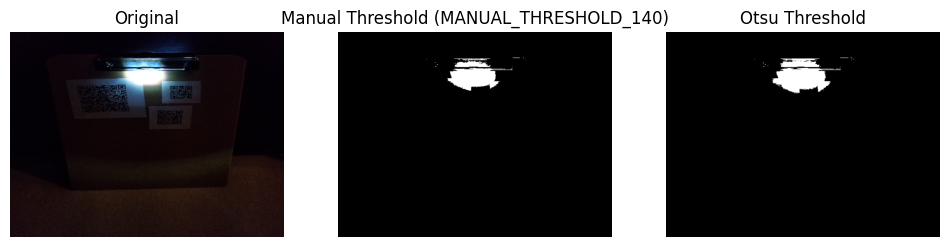

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(prep["enhanced"], cmap='gray')
plt.title(f"Manual Threshold ({prep['method']})")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prep["otsu"], cmap='gray')
plt.title("Otsu Threshold")
plt.axis("off")

plt.show()

## 10. Run and display

In [13]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

folder_path = r"D:\UNIKL\FYP2\QR_data\train\images"

df = run_dataset(folder_path)
display(df)

,file,brightness,method,blur,contrast,quality_status,quality_reason,angle,qr_found,qr_data,decode_method,qr_status,qr_reason,latency_ms
0,blurredimage001.jpg,114.07,MANUAL_THRESHOLD_140,6753.12,255.0,PASS,QUALITY_OK,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,14.44
1,blurredimage002.jpg,139.23,MANUAL_THRESHOLD_140,22686.78,255.0,PASS,QUALITY_OK,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,18.73
2,blurredimage005.jpg,150.11,MANUAL_THRESHOLD_140,6793.55,255.0,PASS,QUALITY_OK,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,62.13
3,blurredimage017.jpg,36.26,MANUAL_THRESHOLD_140,91.44,255.0,REJECT,BLUR,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,64.97
4,blurredimage018.jpg,35.85,MANUAL_THRESHOLD_140,83.82,255.0,REJECT,BLUR,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,63.79
5,blurredimage019.jpg,35.82,MANUAL_THRESHOLD_140,89.32,255.0,REJECT,BLUR,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,59.99
6,blurredimage027.jpg,72.04,MANUAL_THRESHOLD_140,9781.69,255.0,PASS,QUALITY_OK,NaN,False,None,None,NO_QR,QR_NOT_DETECTED,16.49
7,blurredimage032.jpg,143.43,MANUAL_THRESHOLD_140,8664.50,255.0,PASS,QUALITY_OK,78.69,True,http://www.bestekmall.com/,PYZBAR,PASS,QR_DETECTED,61.53
8,blurredimage033.jpg,144.68,MANUAL_THRESHOLD_140,8839.76,255.0,PASS,QUALITY_OK,78.19,True,http://www.bestekmall.com/,PYZBAR,PASS,QR_DETECTED,60.44
9,blurredimage034.jpg,179.17,MANUAL_THRESHOLD_140,11311.01,255.0,PASS,QUALITY_OK,19.17,True,"{""lastNode"":""OAK5"",""cids"":{""pkey"":""18041019482...",PYZBAR,PASS,QR_DETECTED,25.73


## 11. Summary of Result 1


In [14]:
print("QUALITY INSPECTION RESULT")
print(df["quality_status"].value_counts())

print("\nQUALITY REASON")
print(df["quality_reason"].value_counts())

QUALITY INSPECTION RESULT
quality_status
PASS      192
REJECT      8
Name: count, dtype: int64

QUALITY REASON
quality_reason
QUALITY_OK    192
BLUR            8
Name: count, dtype: int64


## 12. Summary of Result 2

In [15]:
print("QR DETECTION RESULT")
print(df["qr_status"].value_counts())

print("\nQR DETECTION REASON")
print(df["qr_reason"].value_counts())

QR DETECTION RESULT
qr_status
NO_QR    130
PASS      70
Name: count, dtype: int64

QR DETECTION REASON
qr_reason
QR_NOT_DETECTED    130
QR_DETECTED         70
Name: count, dtype: int64


## 13. Final Result

In [16]:
# =========================
# FINAL RESULT (COMBINED)
# =========================
df["final_result"] = df.apply(
    lambda row: "PASS" if row["quality_status"] == "PASS" and row["qr_status"] == "PASS"
    else "REJECT",
    axis=1
)

print("\n=== FINAL RESULT SUMMARY ===")
print(df["final_result"].value_counts())


# =========================
# FINAL REASON
# =========================
df["final_reason"] = df.apply(
    lambda row: row["quality_reason"] if row["quality_status"] != "PASS"
    else row["qr_reason"],
    axis=1
)

print("\n=== FINAL REASON SUMMARY ===")
print(df["final_reason"].value_counts())


# =========================
# FINAL PERFORMANCE (%)
# =========================
total = len(df)
pass_count = (df["final_result"] == "PASS").sum()
reject_count = (df["final_result"] == "REJECT").sum()

print("\n=== FINAL PERFORMANCE ===")
print(f"Total Images : {total}")
print(f"PASS         : {pass_count} ({pass_count/total*100:.2f}%)")
print(f"REJECT       : {reject_count} ({reject_count/total*100:.2f}%)")


=== FINAL RESULT SUMMARY ===
final_result
REJECT    130
PASS       70
Name: count, dtype: int64

=== FINAL REASON SUMMARY ===
final_reason
QR_NOT_DETECTED    122
QR_DETECTED         70
BLUR                 8
Name: count, dtype: int64

=== FINAL PERFORMANCE ===
Total Images : 200
PASS         : 70 (35.00%)
REJECT       : 130 (65.00%)


## 13. Save CSV

In [17]:
df.to_csv("qr_quality_and_detection_results_manual.csv", index=False)
print("Saved to qr_quality_and_detection_results_manual.csv")

Saved to qr_quality_and_detection_results_manual.csv


## 14. Evalution Metric

In [18]:
# def get_ground_truth(filename):
#     name = str(filename).lower()

#     if "pass" in name:
#         return "PASS"
#     elif "no_qr" in name:
#         return "NO_QR"
#     else:
#         return "UNKNOWN"

# df["ground_truth"] = df["file"].apply(get_ground_truth)
# df = df[df["ground_truth"] != "UNKNOWN"].copy()

# print(df[["file", "ground_truth"]].head())

In [19]:
import os

output_path = r"D:\UNIKL\FYP2\QR_data\train\labels"

def annotation_label(filename):
    name = os.path.splitext(filename)[0]
    label_file = os.path.join(output_path, name + ".txt")

    if not os.path.exists(label_file):
        return "NO_QR"

    with open(label_file, "r") as f:
        lines = f.readlines()

    if len(lines) > 0:
        return "PASS"
    else:
        return "NO_QR"
    
df["actual_label"] = df["file"].apply(annotation_label)

In [20]:
# =========================
# EVALUATION METRICS
# =========================

# Safety check
if "df" not in globals():
    print(" Error: df not found. Please run dataset cell first.")

else:
    print("=== CHECK LABELS ===")
    # print("Ground Truth:", df["ground_truth"].unique())
    print("Actual Label:", df["actual_label"].unique())
    print("Prediction  :", df["qr_status"].unique())

    # =========================
    # PREPARE DATA
    # =========================

    # y_true = df["ground_truth"].fillna("UNKNOWN")
    # y_pred = df["qr_status"].fillna("UNKNOWN")
    # y_true = df["ground_truth"].fillna("UNKNOWN")
    # y_pred = df["final_result"].fillna("UNKNOWN")
    y_true = df["actual_label"]
    y_pred = df["final_result"]

    # Convert to binary (PASS = 1, others = 0)
    y_true_bin = y_true.apply(lambda x: 1 if x == "PASS" else 0)
    y_pred_bin = y_pred.apply(lambda x: 1 if x == "PASS" else 0)

    # =========================
    # CONFUSION MATRIX
    # =========================
    TP = ((y_true_bin == 1) & (y_pred_bin == 1)).sum()
    TN = ((y_true_bin == 0) & (y_pred_bin == 0)).sum()
    FP = ((y_true_bin == 0) & (y_pred_bin == 1)).sum()
    FN = ((y_true_bin == 1) & (y_pred_bin == 0)).sum()

    # =========================
    # METRICS
    # =========================
    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    # =========================
    # OUTPUT
    # =========================
    print("\n=== CONFUSION MATRIX ===")
    print(f"TP (Correct PASS) : {TP}")
    print(f"TN (Correct NO_QR): {TN}")
    print(f"FP (False PASS)   : {FP}")
    print(f"FN (Missed QR)    : {FN}")

    print("\n=== METRICS ===")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1_score:.4f}")

=== CHECK LABELS ===
Actual Label: ['PASS' 'NO_QR']
Prediction  : ['NO_QR' 'PASS']

=== CONFUSION MATRIX ===
TP (Correct PASS) : 66
TN (Correct NO_QR): 21
FP (False PASS)   : 4
FN (Missed QR)    : 109

=== METRICS ===
Accuracy  : 0.4350
Precision : 0.9429
Recall    : 0.3771
F1 Score  : 0.5388


In [21]:
def evaluate_result(df_eval):
    y_true = df_eval["actual_label"].fillna("UNKNOWN")
    y_pred = df_eval["qr_status"].fillna("UNKNOWN")

    y_true_bin = y_true.apply(lambda x: 1 if x == "PASS" else 0)
    y_pred_bin = y_pred.apply(lambda x: 1 if x == "PASS" else 0)

    TP = ((y_true_bin == 1) & (y_pred_bin == 1)).sum()
    TN = ((y_true_bin == 0) & (y_pred_bin == 0)).sum()
    FP = ((y_true_bin == 0) & (y_pred_bin == 1)).sum()
    FN = ((y_true_bin == 1) & (y_pred_bin == 0)).sum()

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    return {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }




## Test many threshold

In [22]:
def run_dataset_with_threshold(folder_path, manual_threshold):
    results = []

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue

        img = cv2.imread(file_path)
        if img is None:
            continue

        prep = preprocess_image(img, manual_threshold=manual_threshold)

        # replace this part with your existing QR detection logic
        decoded_objects = pyzbar.decode(prep["enhanced"])

        qr_status = "PASS" if len(decoded_objects) > 0 else "NO_QR"

        results.append({
            "file": file_name,
            "qr_status": qr_status,
            "brightness": prep["brightness"],
            "method": prep["method"]
        })

    return pd.DataFrame(results)

In [23]:
threshold_list = [ 110, 120, 127, 140, 160]
summary = []

for th in threshold_list:
    df_test = run_dataset_with_threshold(folder_path, manual_threshold=th)

    df_test["actual_label"] = df_test["file"].apply(annotation_label)
    df_test = df_test[df_test["actual_label"] != "UNKNOWN"].copy()

    metrics = evaluate_result(df_test)

    summary.append({
        "threshold": th,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "TP": metrics["TP"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"]
    })

summary_df = pd.DataFrame(summary).sort_values(by="f1_score", ascending=False)
display(summary_df)

,threshold,accuracy,precision,recall,f1_score,TP,TN,FP,FN
1,120,0.565,0.958333,0.525714,0.678967,92,21,4,83
3,140,0.550,0.938144,0.520000,0.669118,91,19,6,84
0,110,0.550,0.956989,0.508571,0.664179,89,21,4,86
2,127,0.545,0.956522,0.502857,0.659176,88,21,4,87
4,160,0.510,0.942529,0.468571,0.625954,82,20,5,93


In [24]:
best_row = summary_df.iloc[0]
print("Best threshold =", best_row["threshold"])
print(best_row)

Best threshold = 120.0
threshold    120.000000
accuracy       0.565000
precision      0.958333
recall         0.525714
f1_score       0.678967
TP            92.000000
TN            21.000000
FP             4.000000
FN            83.000000
Name: 1, dtype: float64
